In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Guardamos la URL en una variable
url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"

# Leemos el archivo directamente desde internet
df = pd.read_csv(url)

# Mostramos las primeras 5 filas para verificar
df.head()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN


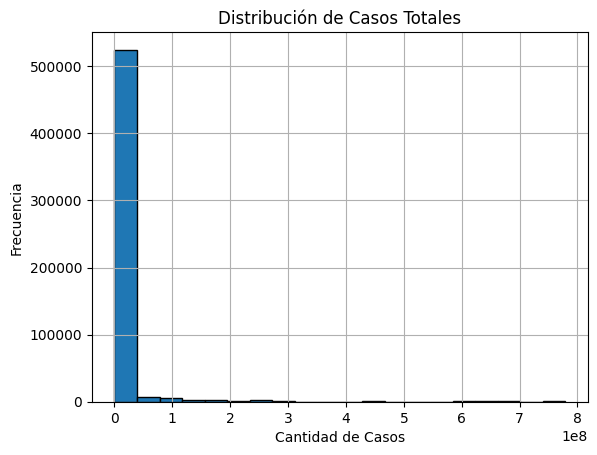

In [7]:




# 2. Crear el histograma
# 'bins' es la cantidad de barras, puedes ajustarlo
df['total_cases'].hist(bins=20, edgecolor='black')

# 3. Personalizar (opcional pero recomendado)
plt.title('Distribución de Casos Totales')
plt.xlabel('Cantidad de Casos')
plt.ylabel('Frecuencia')

# 4. Mostrar
plt.show()

In [8]:
def analizar_vacios_y_ceros(df):
    # 1. Identificar columnas por tipo
    cols_numericas = df.select_dtypes(include=['number']).columns
    cols_categoricas = df.select_dtypes(exclude=['number']).columns

    # 2. Crear un diccionario para guardar los resultados
    resumen = []

    # Analizar numéricas (buscamos nulos y ceros)
    for col in cols_numericas:
        nulos = df[col].isnull().sum()
        ceros = (df[col] == 0).sum()
        resumen.append({
            'Columna': col,
            'Tipo': 'Numérica',
            'Nulos': nulos,
            'Ceros': ceros,
            '% Faltante/Cero': round(((nulos + ceros) / len(df)) * 100, 2)
        })

    # Analizar categóricas (buscamos solo nulos)
    for col in cols_categoricas:
        nulos = df[col].isnull().sum()
        resumen.append({
            'Columna': col,
            'Tipo': 'Categórica',
            'Nulos': nulos,
            'Ceros': 'N/A', # No tiene sentido buscar ceros en texto
            '% Faltante': round((nulos / len(df)) * 100, 2)
        })

    # Convertir a DataFrame para que se vea bonito en VS Code
    return pd.DataFrame(resumen)

# --- Cómo usarla ---
# resultado = analizar_vacios_y_ceros(df)
# print(resultado)

In [ ]:
# Llamamos a la función y guardamos el resultado en una variable
resumen_datos = analizar_vacios_y_ceros(df)

# Tabla con los resultados
resumen_datos

,Columna,Tipo,Nulos,Ceros,% Faltante/Cero,% Faltante
0,total_cases,Numérica,12348,29991,7.49,NaN
1,new_cases,Numérica,16204,350404,64.84,NaN
2,new_cases_smoothed,Numérica,17413,207058,39.70,NaN
3,total_cases_per_million,Numérica,12348,29991,7.49,NaN
4,new_cases_per_million,Numérica,16204,350404,64.84,NaN
...,...,...,...,...,...,...
56,human_development_index,Numérica,565377,0,100.00,NaN
57,country,Categórica,0,N/A,NaN,0.00
58,date,Categórica,0,N/A,NaN,0.00
59,code,Categórica,24112,N/A,NaN,4.26


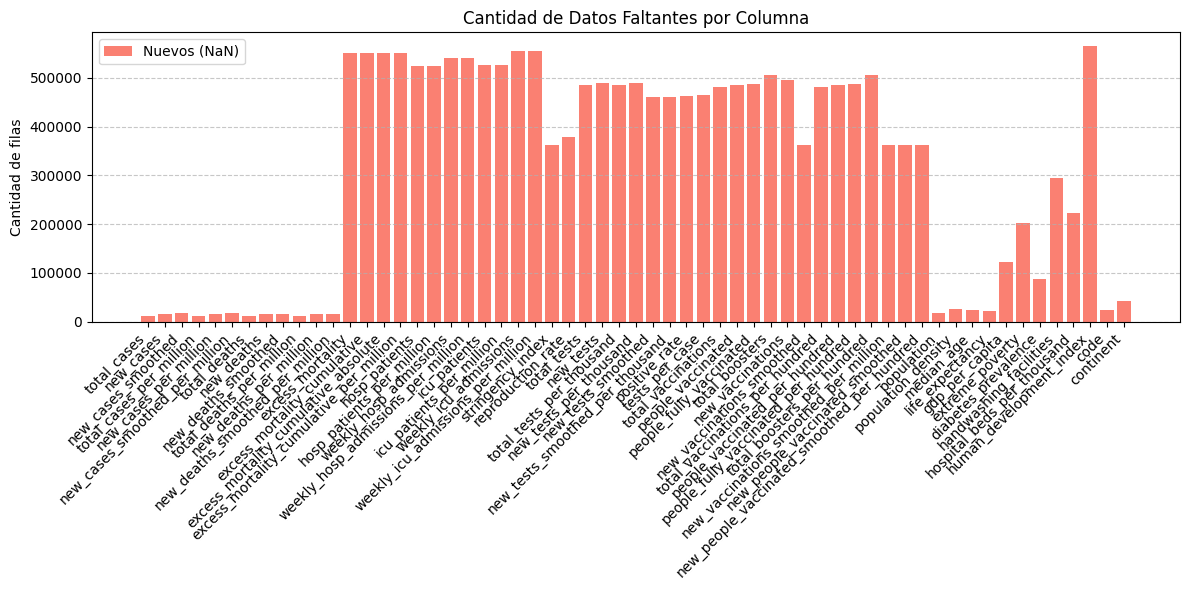

In [10]:
import matplotlib.pyplot as plt

# 1. Preparar los datos (usamos el DataFrame que generó tu función)
# Vamos a graficar solo las columnas que tengan algún problema para no saturar el gráfico
df_grafico = resumen_datos[resumen_datos['Nulos'] > 0].copy()

# 2. Configurar el tamaño del gráfico
plt.figure(figsize=(12, 6))

# 3. Crear barras para Nulos
plt.bar(df_grafico['Columna'], df_grafico['Nulos'], color='salmon', label='Nuevos (NaN)')

# 4. Personalizar
plt.xticks(rotation=45, ha='right') # Rotar nombres para que se lean bien
plt.title('Cantidad de Datos Faltantes por Columna')
plt.ylabel('Cantidad de filas')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Ajustar y mostrar
plt.tight_layout()
plt.show()

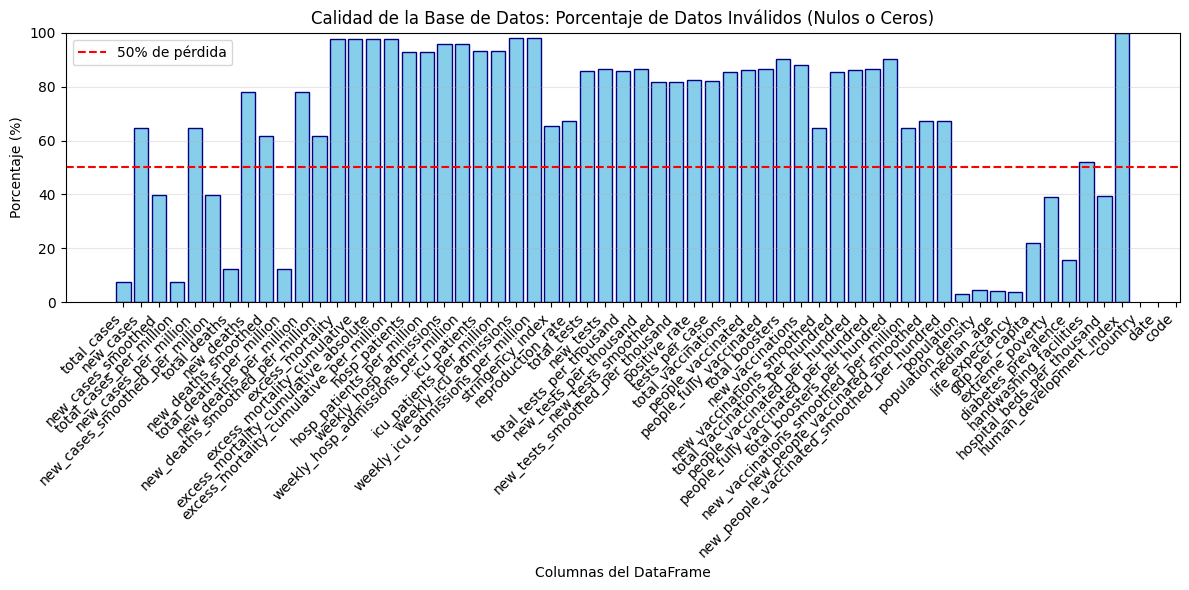

In [11]:
import matplotlib.pyplot as plt

# 1. Configurar el estilo y tamaño
plt.figure(figsize=(12, 6))

# 2. Crear las barras
# Usamos el índice de las columnas en el eje X y los porcentajes en el Y
plt.bar(resumen_datos['Columna'], resumen_datos['% Faltante/Cero'], color='skyblue', edgecolor='navy')

# 3. Añadir una línea de advertencia (ej. al 50%)
plt.axhline(y=50, color='red', linestyle='--', label='50% de pérdida')

# 4. Personalización estética
plt.xticks(rotation=45, ha='right')
plt.title('Calidad de la Base de Datos: Porcentaje de Datos Inválidos (Nulos o Ceros)')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas del DataFrame')
plt.ylim(0, 100) # El porcentaje va de 0 a 100
plt.legend()
plt.grid(axis='y', alpha=0.3)

# 5. Mostrar
plt.tight_layout()
plt.show()

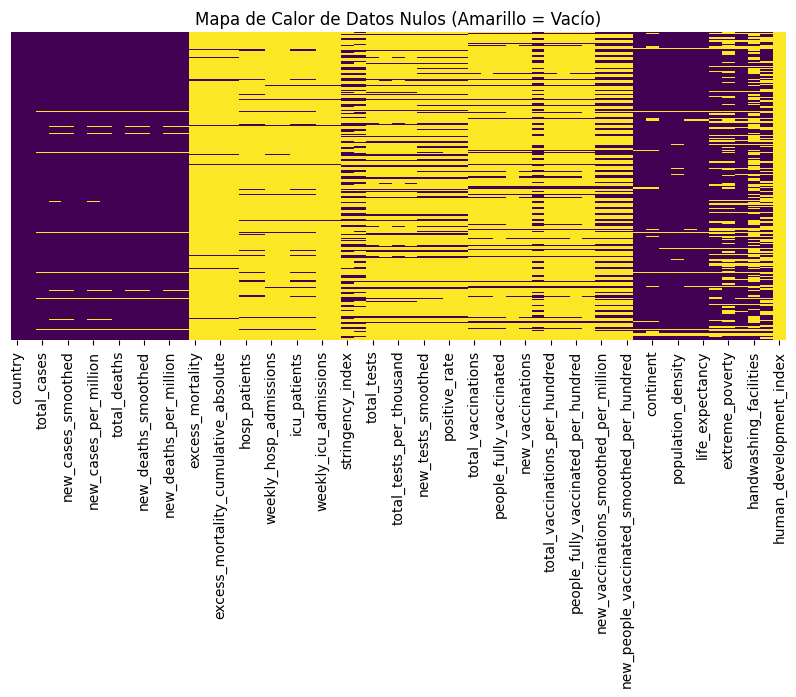

In [13]:
import seaborn as sns

plt.figure(figsize=(10, 4))
# Creamos un mapa de calor donde lo amarillo es nulo y lo morado es dato real
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Calor de Datos Nulos (Amarillo = Vacío)')
plt.show()

In [15]:
# 1. Elegimos la columna que queremos graficar (ejemplo: 'new_cases')
columna_objetivo = 'new_cases' 

# 2. Filtramos: Eliminamos Nulos Y también los Ceros (si consideras que el 0 no aporta al análisis)
df_filtrado = df[df[columna_objetivo].notnull() & (df[columna_objetivo] > 0)]

# 3. (Opcional) Filtrar por un país para que no sea una masa de datos gigante
df_pais = df_filtrado[df_filtrado['country'] == 'Colombia']

print(f"Datos originales: {len(df)}")
print(f"Datos después de limpiar: {len(df_pais)}")

Datos originales: 565377
Datos después de limpiar: 940


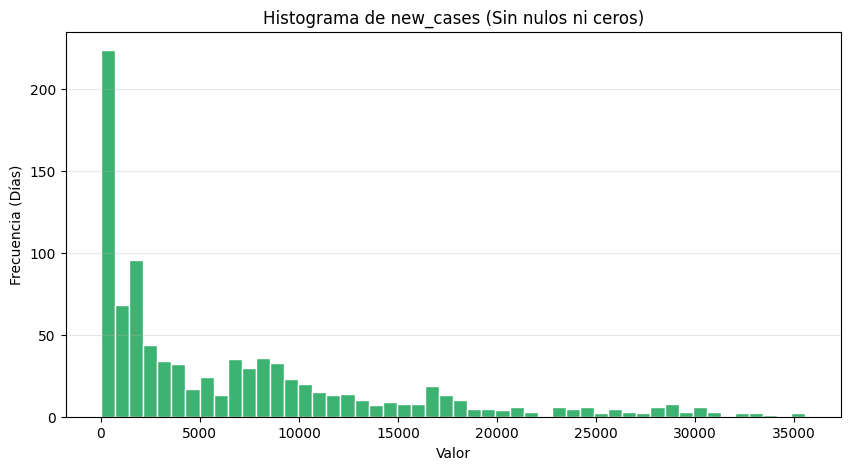

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Graficamos los datos limpios
# Usamos un color distinto para diferenciarlo del anterior
plt.hist(df_pais[columna_objetivo], bins=50, color='mediumseagreen', edgecolor='white')

plt.title(f'Histograma de {columna_objetivo} (Sin nulos ni ceros)')
plt.xlabel('Valor')
plt.ylabel('Frecuencia (Días)')
plt.grid(axis='y', alpha=0.3)

plt.show()